## Lab 1 (Cameron Mangione)

Group number: 2

Group members: Sydney Golden, Porhay Rouen, Cameron Mangione

## Examining Salaries of Data Scientists

### Project Background

Despite having one more year until our program ends, finding a job post-graduation is a hot (and anxiety-inducing) topic in our cohort. 
Our proactive team would like to get a head start on the job searching process, and will be analyzing the salaries of data scientists throughout the 2020s. 
With the rise of AI and automation, the data science job market has seen significant shifts in compensation, remote work adoption, and demand across experience levels. 
Understanding these trends will help us make informed decisions about career paths, specializations, and salary negotiations upon graduation.

### Dataset Description

We merged two publicly available Kaggle datasets:

- [Data Science Salaries 2023](https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023) — focused on 2023 salary records
- [Data Science Job Salaries](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries) — covers the broader 2020s

Both datasets share the same schema and were combined using an outer join to preserve all records across years. 
The merged dataset captures a wide range of data science roles, experience levels, company sizes, and geographic locations, making it well-suited for exploring salary trends across multiple dimensions.

## EDA

### Description of the Dataset Source

The data comes from two Kaggle datasets containing self-reported and scraped salary information for data science roles worldwide, covering work years from 2020 to 2023. 
The datasets were merged using an outer join on shared columns to form a single comprehensive dataset.

### Definition of Key Variables

| Variable | Description |
|---|---|
| `work_year` | The year the salary was paid |
| `experience_level` | EN (Entry), MI (Mid), SE (Senior), EX (Executive) |
| `employment_type` | FT (Full-time), PT (Part-time), CT (Contract), FL (Freelance) |
| `job_title` | The role or position held |
| `salary` | Gross salary in local currency |
| `salary_currency` | ISO 4217 currency code |
| `salary_in_usd` | Salary converted to USD (primary response variable) |
| `employee_residence` | Employee country of residence (ISO 3166) |
| `remote_ratio` | 0 = on-site, 50 = hybrid, 100 = fully remote |
| `company_location` | Country of employer headquarters |
| `company_size` | S (Small), M (Medium), L (Large) |

### Data Types

- **Numerical:** `work_year`, `salary`, `salary_in_usd`, `remote_ratio`
- **Categorical (Nominal):** `employment_type`, `job_title`, `salary_currency`, `employee_residence`, `company_location`
- **Categorical (Ordinal):** `experience_level` (EN < MI < SE < EX), `company_size` (S < M < L)

### Handling Missing Values

No missing values were found in either dataset. The outer join did not introduce nulls as both datasets share identical column structures.

### Data Preprocessing Steps

1. Downloaded both datasets from Kaggle
2. Verified that both datasets share the same column names and types
3. Merged the two datasets using an outer join to retain all records
4. Removed duplicate rows that appeared in both datasets
5. Confirmed no missing values after merging

### Identification of Predictor and Response Variables

**Response Variable:** `salary_in_usd` — the primary outcome we aim to understand and predict

**Predictor Variables:**
- `experience_level` — expected to be one of the strongest predictors
- `job_title` — different roles command different pay
- `company_size` — larger companies may offer higher salaries
- `remote_ratio` — remote work adoption may correlate with compensation
- `employment_type` — full-time vs. contract roles differ in pay structure
- `work_year` — salary trends may shift over time
- `company_location` / `employee_residence` — geographic factors influence salary


## Summary Statistics & Visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/porhay007/GROUP-PROJECT-2-DATA-5322/refs/heads/main/ds_salaries_merged.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
4,5,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  4362 non-null   int64 
 1   work_year           4362 non-null   int64 
 2   experience_level    4362 non-null   object
 3   employment_type     4362 non-null   object
 4   job_title           4362 non-null   object
 5   salary              4362 non-null   int64 
 6   salary_currency     4362 non-null   object
 7   salary_in_usd       4362 non-null   int64 
 8   employee_residence  4362 non-null   object
 9   remote_ratio        4362 non-null   int64 
 10  company_location    4362 non-null   object
 11  company_size        4362 non-null   object
dtypes: int64(5), object(7)
memory usage: 409.1+ KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
ID                    0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [5]:
df.describe()

,ID,work_year,salary,salary_in_usd,remote_ratio
count,4362.000000,4362.000000,4.362000e+03,4362.000000,4362.000000
mean,2181.500000,2022.238881,2.092457e+05,134053.558230,49.701972
std,1259.345266,0.768427,8.496508e+05,64797.957697,48.325818
min,1.000000,2020.000000,4.000000e+03,2859.000000,0.000000
25%,1091.250000,2022.000000,9.391825e+04,90000.000000,0.000000
50%,2181.500000,2022.000000,1.350000e+05,130000.000000,50.000000
75%,3271.750000,2023.000000,1.800000e+05,173000.000000,100.000000
max,4362.000000,2023.000000,3.040000e+07,600000.000000,100.000000


### Plot 1: Average Salary by Job Title

This horizontal bar chart displays the average salary (USD) across different data science job titles, sorted from lowest to highest pay, making it easy to compare roles at a glance.

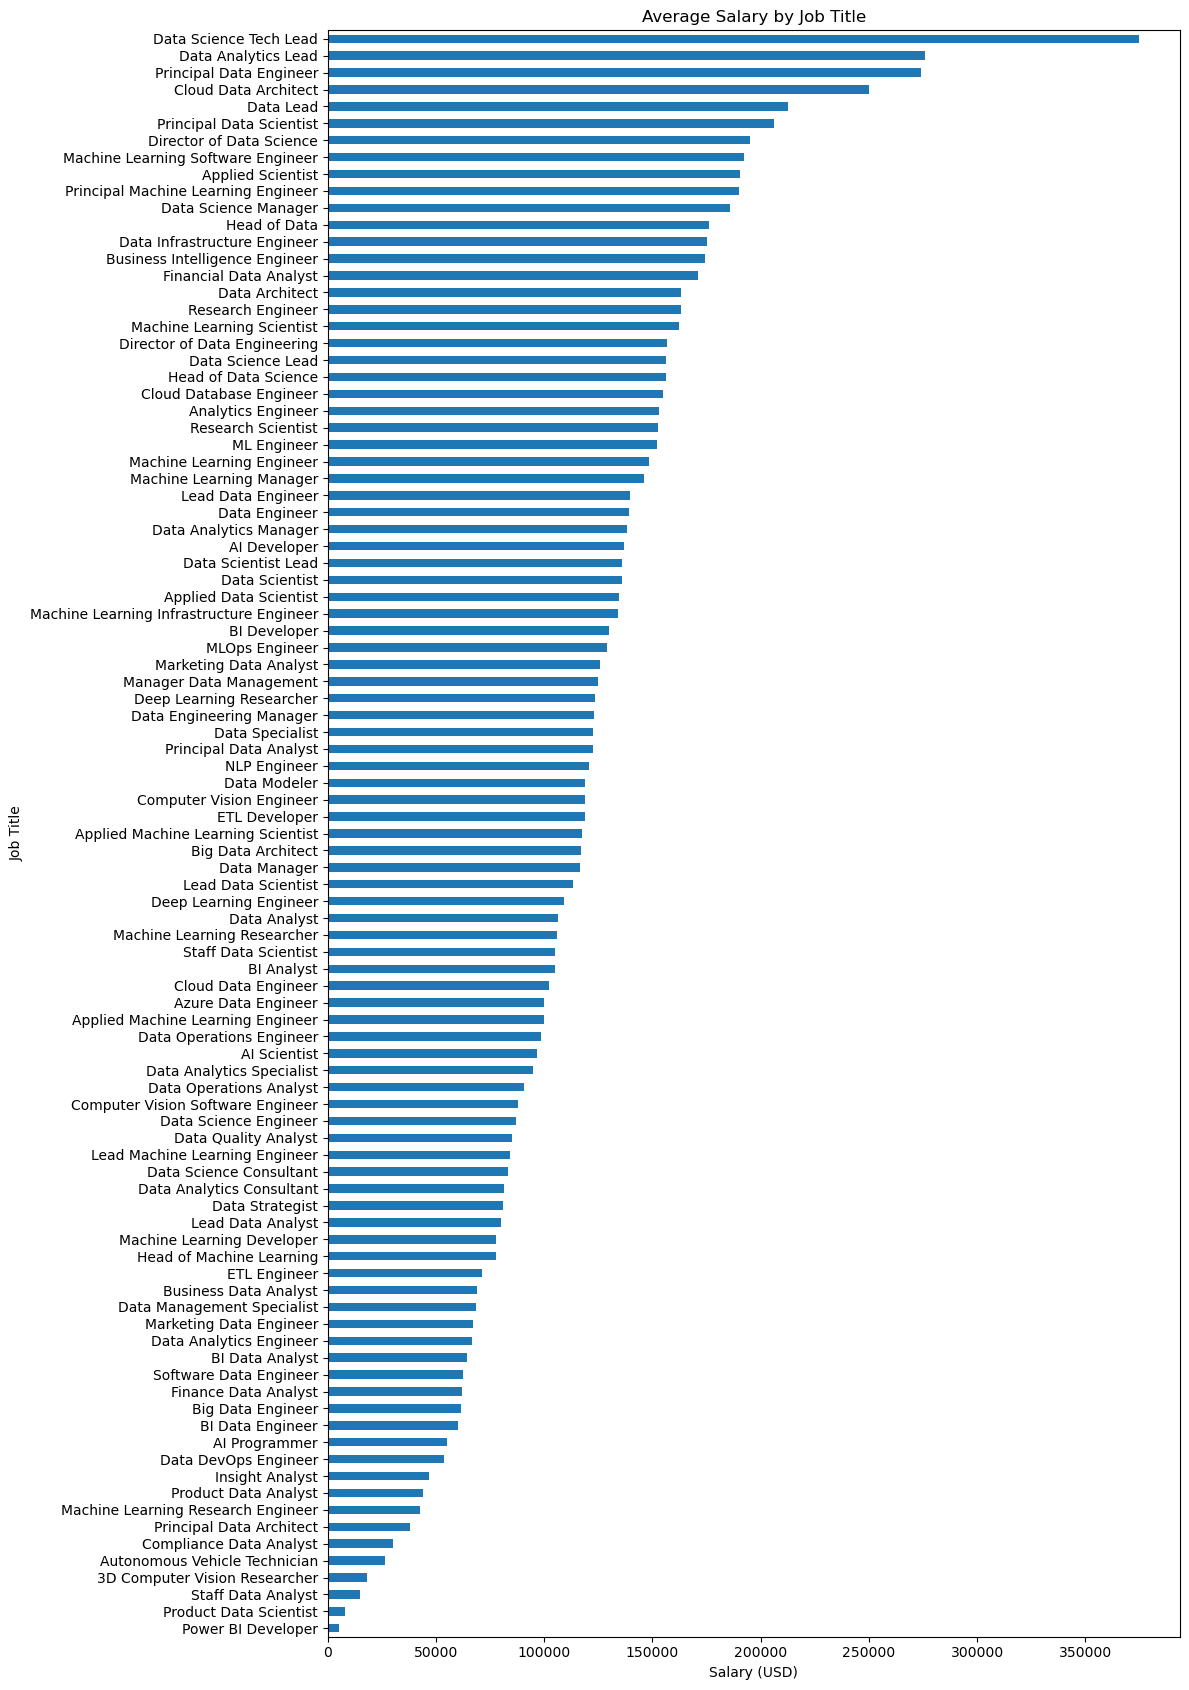

In [6]:
# Plot 1: Average Salary by Job Title
avg_salary = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=True)
plt.figure(figsize=(12, 17))
avg_salary.plot(kind='barh')
plt.title('Average Salary by Job Title')
plt.xlabel('Salary (USD)')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

### Plot 2: Employee Count by Experience Level and Job Title Count

This bar chart shows the distribution of employees across experience levels, giving an overview of the workforce composition in the dataset.

The second bar chart shows a count of job titles in our dataset, showing the most common titles in the industry.

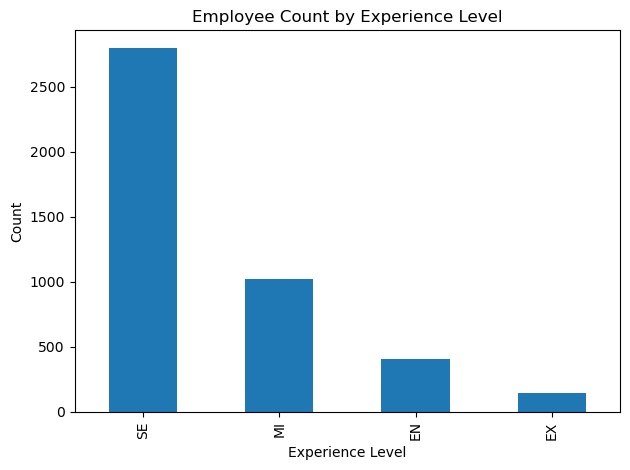

In [7]:
# Plot 2: Count by Experience Level
plt.figure()
df['experience_level'].value_counts().plot(kind='bar')
plt.title('Employee Count by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

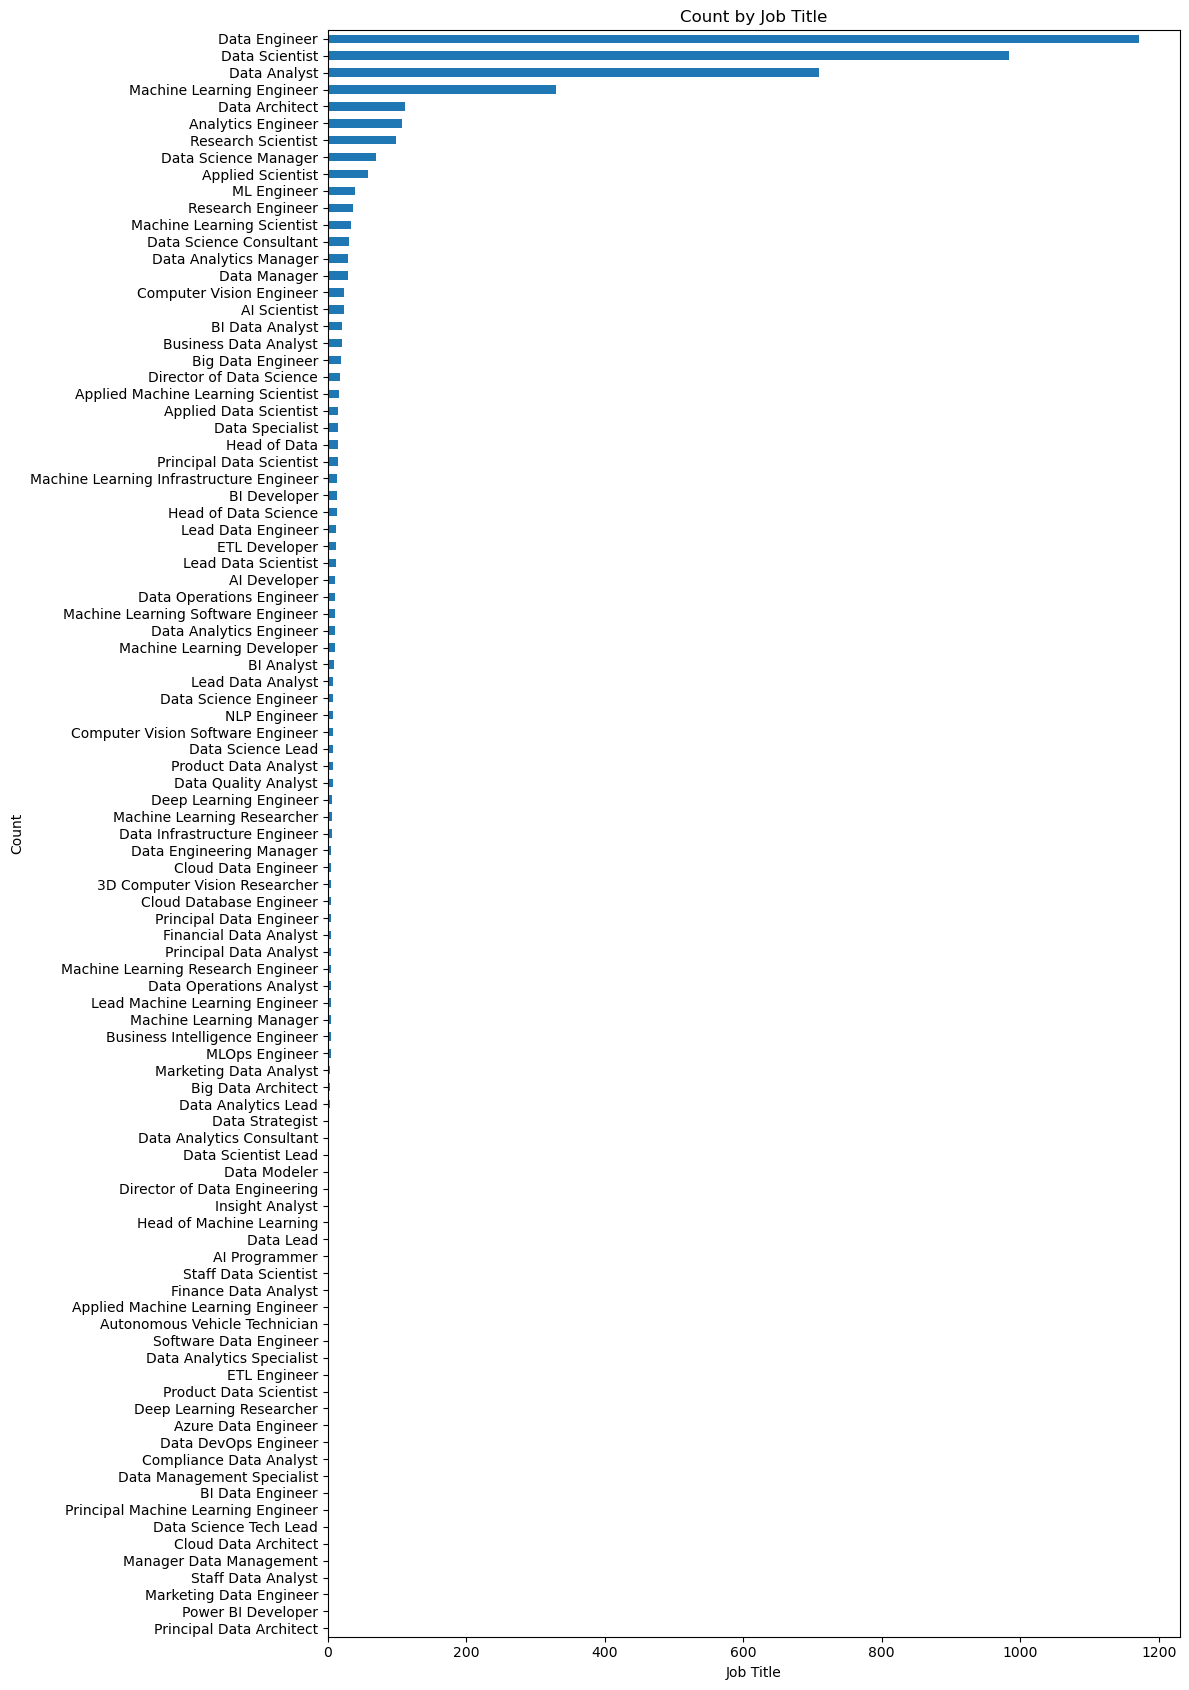

In [8]:
# Plot 2.1: Count by Job Title
plt.figure(figsize=(12, 17))
df['job_title'].value_counts().sort_values(ascending=True).plot(kind='barh')
plt.title('Count by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Plot 3: Average Salary by Experience Level

This bar chart illustrates how average salaries increase with experience level, reflecting the expected pay progression from entry-level (EN) to executive (EX) roles.

A copy of our dataset was made here to order our categorical variables into values that are more easily interpretable.

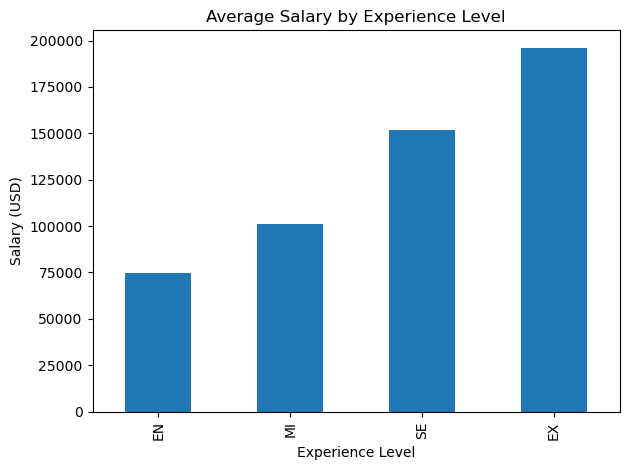

In [9]:
# Plot 3: Average Salary by Experience Level ordered by experience level

df1 = df.copy()
order = ['EN','MI','SE','EX']
order2 = ['S','M','L']
df1['experience_level'] = pd.Categorical(df1['experience_level'], categories=order, ordered=True)
df1['company_size'] = pd.Categorical(df1['company_size'], categories=order2, ordered=True)

plt.figure()
df1.groupby('experience_level', observed=True)['salary_in_usd'].mean().plot(kind='bar')
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

### Plot 4: Remote Work Distribution

This bar chart shows how common different remote work arrangements are, broken down by remote ratio (0 = on-site, 50 = hybrid, 100 = fully remote).

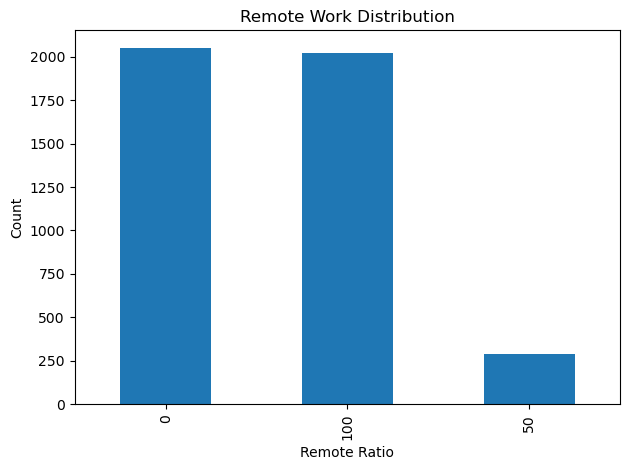

In [10]:
# Plot 4: Remote Ratio Distribution
plt.figure()
df['remote_ratio'].value_counts().plot(kind='bar')
plt.title('Remote Work Distribution')
plt.xlabel('Remote Ratio')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Plot 5: Histograms of Numeric Columns

These histograms display the frequency distributions of salary, salary in USD, and remote ratio, helping identify the shape, spread, and skewness of each numeric variable.

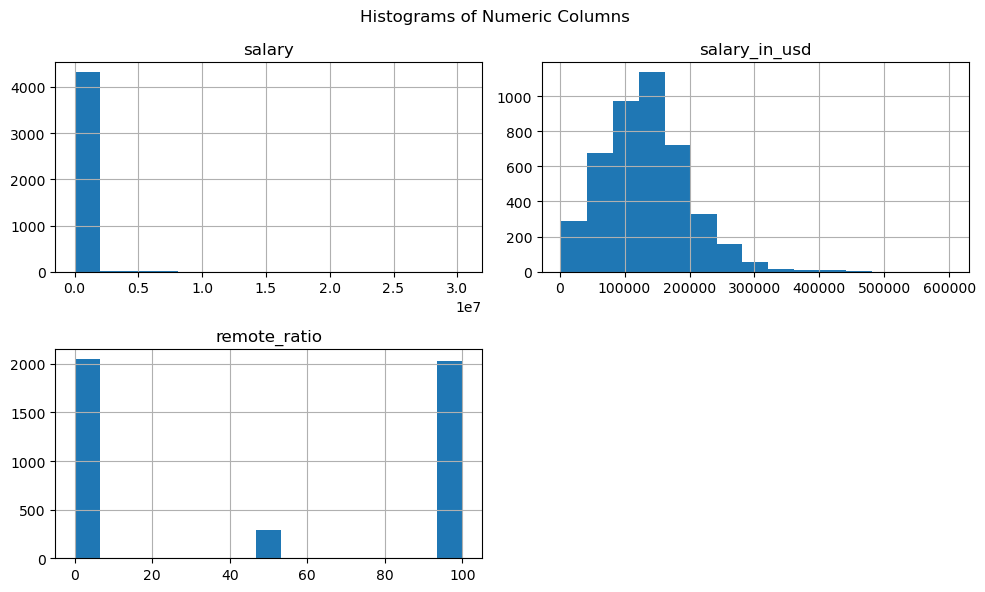

In [11]:
# Histograms
numeric_columns = ['salary', 'salary_in_usd', 'remote_ratio']
df[numeric_columns].hist(bins=15, figsize=(10, 6))
plt.suptitle('Histograms of Numeric Columns')
plt.tight_layout()
plt.show()

### Plot 6: Salary Distribution by Experience Level (Boxplot)

This boxplot compares salary ranges across experience levels, revealing the median, spread, and any outliers within each group.

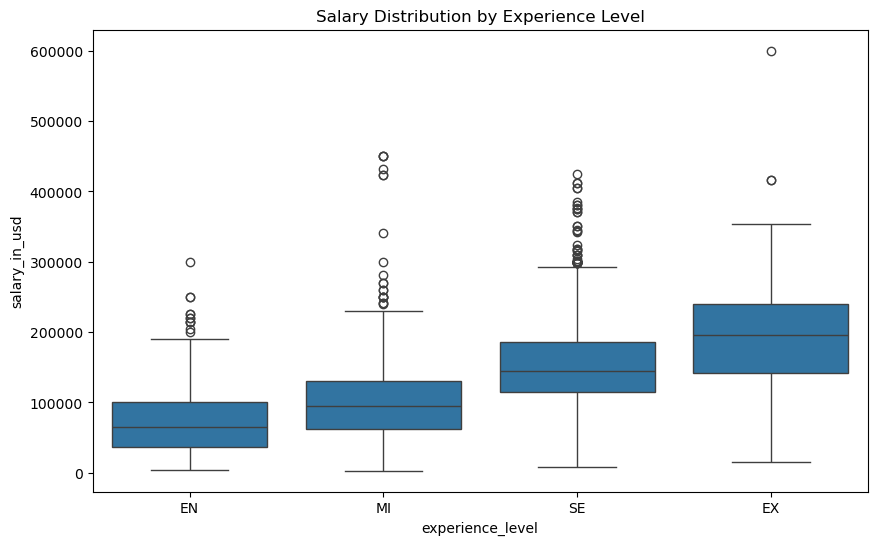

In [12]:
# Boxplot: Salary by Experience Level
plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df1)
plt.title('Salary Distribution by Experience Level')
plt.show()

### Plot 7: Salary Distribution by Company Size (Boxplot)

This boxplot compares salary distributions across small, medium, and large companies, showing how company size relates to compensation levels.

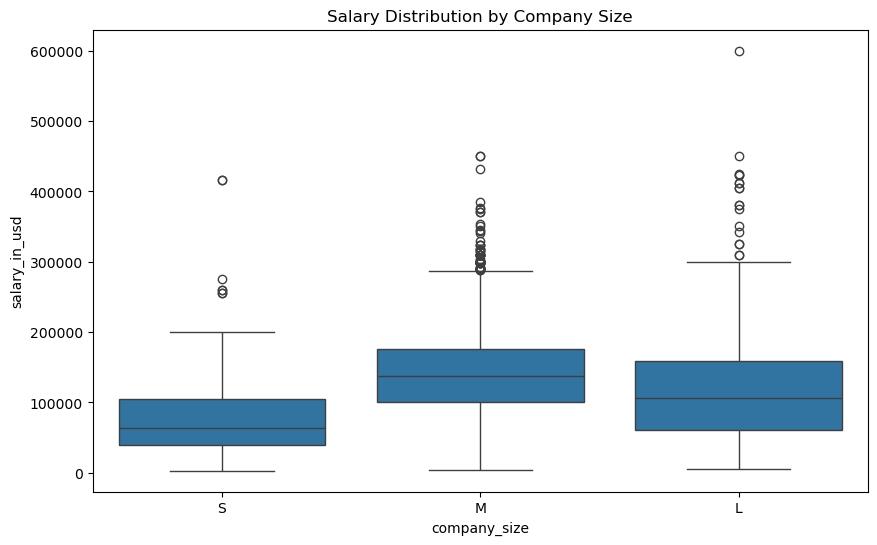

In [13]:
# Boxplot: Salary by Company Size
plt.figure(figsize=(10, 6))
sns.boxplot(x='company_size', y='salary_in_usd', data=df1)
plt.title('Salary Distribution by Company Size')
plt.show()

### Plot 8: Scatterplots

These scatterplots explore salary relationships: the first shows salary by experience level colored by employment type, and the second tracks salary trends over work years sized and colored by remote ratio.

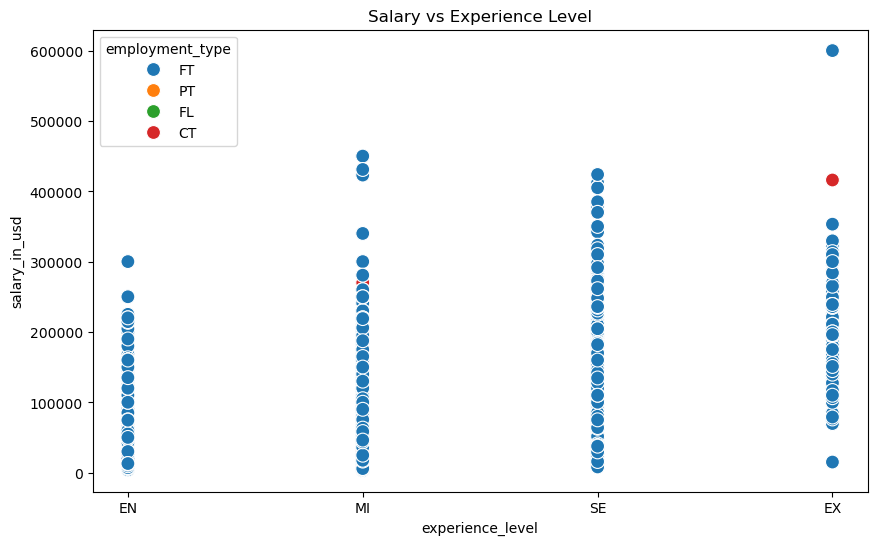

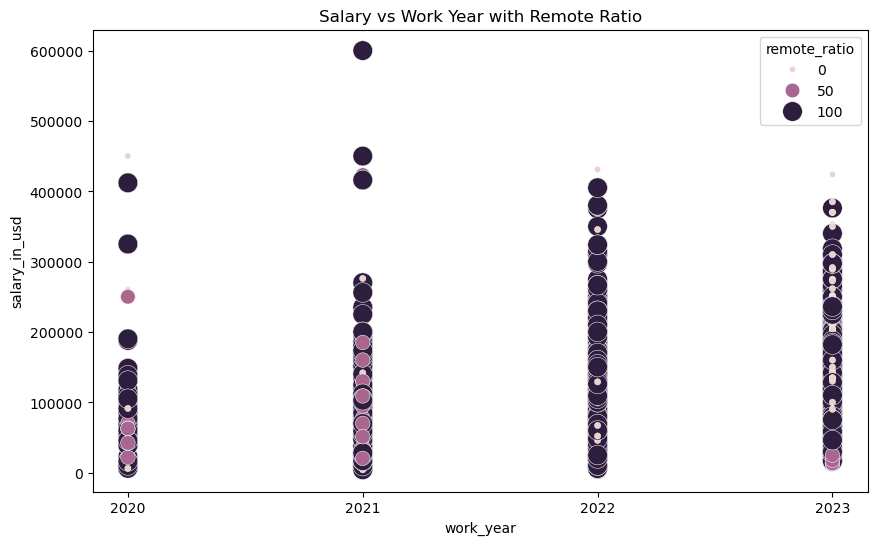

In [14]:
# Scatterplot: Salary vs Experience Level
plt.figure(figsize=(10, 6))
sns.scatterplot(x='experience_level', y='salary_in_usd', hue='employment_type', data=df1, s=100)
plt.title('Salary vs Experience Level')
plt.show()

# Scatterplot: Salary vs Work Year
plt.figure(figsize=(10, 6))
xlims = [2020,2021,2022,2023]
sns.scatterplot(x='work_year', y='salary_in_usd', hue='remote_ratio', size='remote_ratio', sizes=(20, 200), data=df)
plt.title('Salary vs Work Year with Remote Ratio')
plt.xticks(ticks=xlims)
plt.show()

### Plot 9: Correlation Heatmap

This heatmap shows pairwise correlations between numeric variables. Warmer colors (red) indicate positive correlation and cooler colors (blue) indicate negative correlation, with values annotated in each cell.

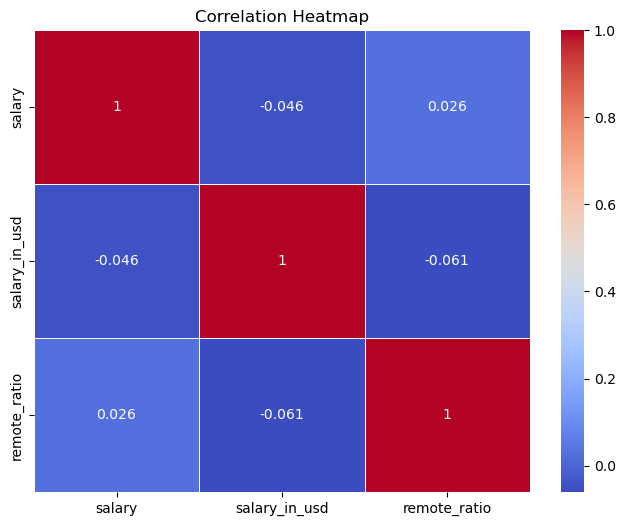

In [15]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Plot 10: Violinplots 

The violinplots show a more comprehensive breakdown of the employment types and how they breakdown for experience levels and salary.

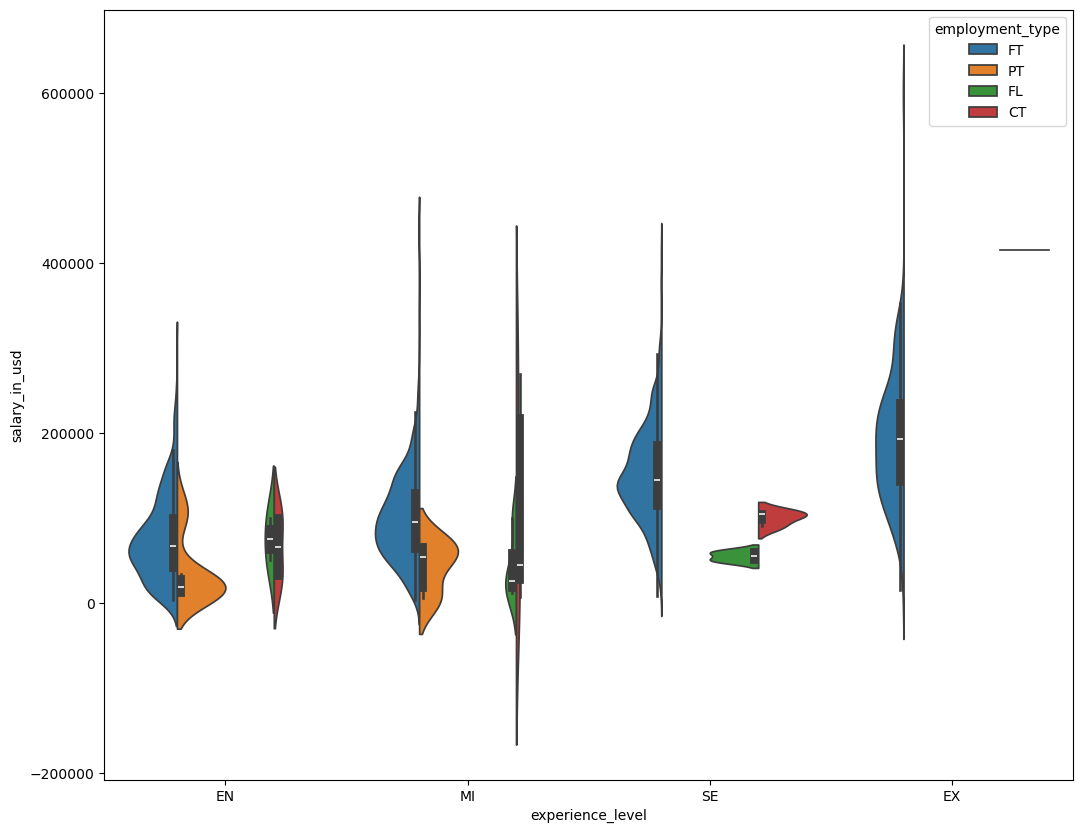

In [16]:
plt.figure(figsize=(12.5,10))
sns.violinplot(x='experience_level', y='salary_in_usd', hue='employment_type', data=df, split=True, order = ['EN','MI','SE','EX'])
plt.show()